# Customer Churn Prediction for SyriaTel

# 1. Business Understanding

## 1.1 Overview
Customer churn is a critical issue for SyriaTel, directly affecting profitability and long-term business sustainability. This project aims to develop a machine learning-based churn prediction model to identify customers who are likely to leave. Therefore, through the analysis of historical customer data and predictive analysis, retention strategies can be applied to encourage customers to stay, thereby reducing churn rates and improving customer loyalty.

## 1.2 Problem Statement
The company wants to predict customer churn using historical customer data. By identifying key factors contributing to customer churn, in advance, SyriaTel can take necessary measures, such as offering personalized incentives, improving customer service, or customizing marketing campaigns.

## 1.3 Business Objective
SyriaTel aims to improve customer retention by proactively identifying customers likely to churn. Churn (whether a customer will leave the service) is a significant problem that has an immediate impact on profitability and sustainability. Retaining existing customers is more cost-effective than acquiring new ones, making churn prediction an essential business goal.

## 1.4 Metrics of Success
The projects' success can be measured by:

**1.4.1 Model Performance**.
- Conducting and analyzing accuracy, precision, recall, F1-score, or ROC-AUC for churn prediction.

**1.4.2 Business Impact**.
- Reducing churn rate over a defined period.

**1.4.3 Actionable Insights**.
- Identifying factors that influence churn, leading to targeted business interventions.

# 2. Data Understanding

In [2]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import warnings
# warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from scipy import stats

In [3]:
#open the file and load it into a DataFrame
with open("Data\SyriaTel Customer Churn.csv", "r") as file:
    df = pd.read_csv(file)

#expand the number of columns shown
pd.set_option("display.max_columns", None)
#display the first 5 rows
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
#display the last 5 rows
df.tail()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False
3332,TN,74,415,400-4344,no,yes,25,234.4,113,39.85,265.9,82,22.60,241.4,77,10.86,13.7,4,3.70,0,False


In [5]:
#check for data summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   str    
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   str    
 4   international plan      3333 non-null   str    
 5   voice mail plan         3333 non-null   str    
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   int64  
 15

**The dataset has 3,333 rows and 21 columns**

1. There is 1 column (churn) with a boolean data type. (target variable)
2. There are 8 columns with float data types.
3. There are 8 columns with int data types.
4. There are 4 columns with object data types.

In [6]:
#check for unique values on the target variable
df ["churn"] .unique()

array([False,  True])

- The churn column has only two unique values - True and False since it's a boolean

In [7]:
#check no. of occurences of unique values
df['churn'].value_counts()

churn
False    2850
True      483
Name: count, dtype: int64

- There are 483 instances where the "churn" value is True, indicating customers who churned.
- There are 2,850 instances where the "churn" value is False, indicating customers who did not churn.

In [8]:
#check summary statistics for numerical variables
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [9]:
#checking statistical summary for categorical variables
df.describe(include="O")

C:\Users\Felix\AppData\Local\Temp\ipykernel_3644\4086371946.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="O")


,state,phone number,international plan,voice mail plan
count,3333,3333,3333,3333
unique,51,3333,2,2
top,WV,382-4657,no,no
freq,106,1,3010,2411


In [10]:
#check for missing values
df.isnull().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

- The dataset has no missing values.

In [11]:
#calculate the churn rate
churn_rate = df["churn"].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 14.49%


## 3. Data Preparation

### 3.1 Data Cleaning

- The Dataset has no missing values.

In [12]:
#check for duplicate rows
df.duplicated().sum()

np.int64(0)

- The dataset has no duplicate entries.


### 3.2 Format Data

In [13]:
#replacing the whitespaces in column names to underscores
df.columns = df.columns.str.replace(" ", "_")

#changing column names to capitalize the beginning of words
df.columns = df.columns.str.title()

#create a copy of the original dataframe(df)
data = df.copy()

## 3.3. Exploratory Data Analysis (EDA)

### 3.3.1 Univariate Analysis

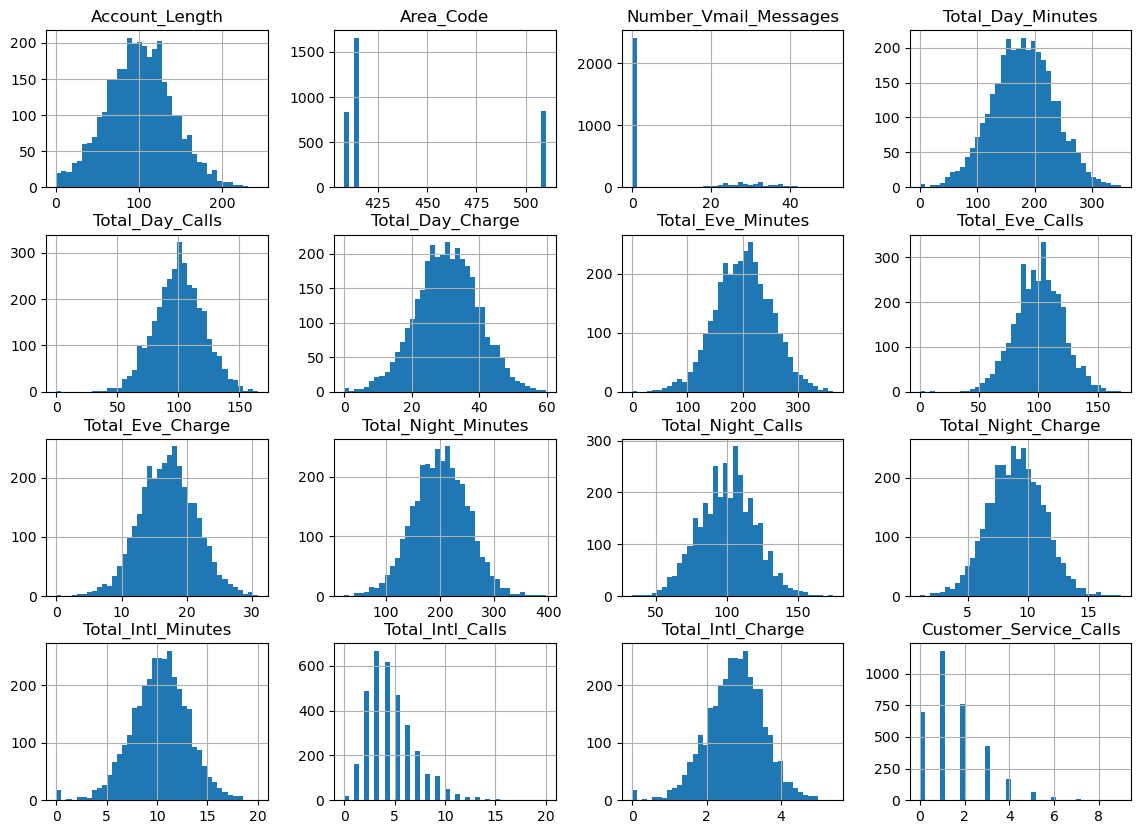

In [14]:
#check data distribution for numeric features
df.hist(bins=40, figsize=(14,10));

**Observation**
- Majority of our numeric features appear to be approximately normally distributed

In [15]:
print(df.columns.tolist())

['State', 'Account_Length', 'Area_Code', 'Phone_Number', 'International_Plan', 'Voice_Mail_Plan', 'Number_Vmail_Messages', 'Total_Day_Minutes', 'Total_Day_Calls', 'Total_Day_Charge', 'Total_Eve_Minutes', 'Total_Eve_Calls', 'Total_Eve_Charge', 'Total_Night_Minutes', 'Total_Night_Calls', 'Total_Night_Charge', 'Total_Intl_Minutes', 'Total_Intl_Calls', 'Total_Intl_Charge', 'Customer_Service_Calls', 'Churn']


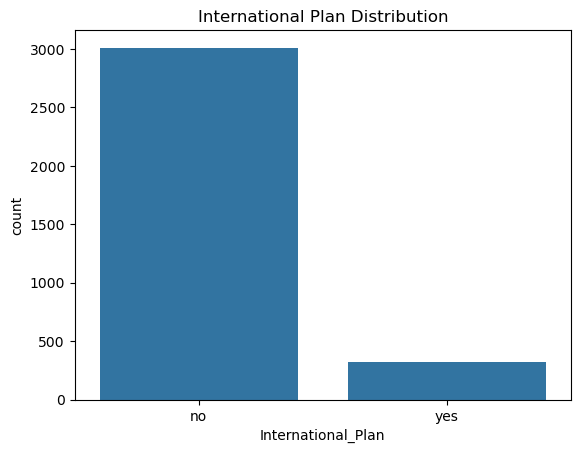

In [16]:
#plot international plan distribution
sns.countplot(data=df, x="International_Plan")
plt.title("International Plan Distribution");

**Observation**
- Majority of the customers are not registered for the international plan.

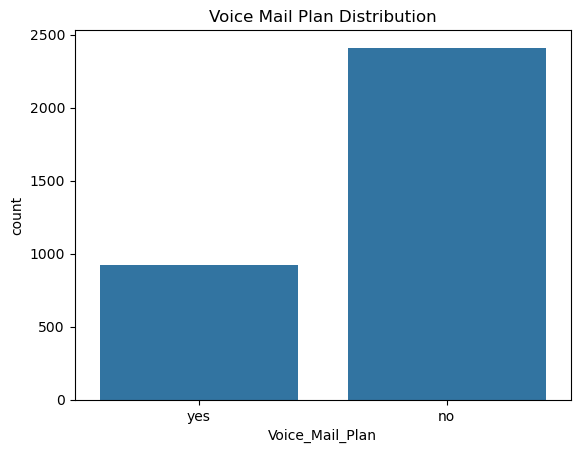

In [17]:
#plot voice mail plan distribution
sns.countplot(data=df, x="Voice_Mail_Plan")
plt.title("Voice Mail Plan Distribution");

**Observation**
- Majority of the customers have not registered for a voice mail plan.

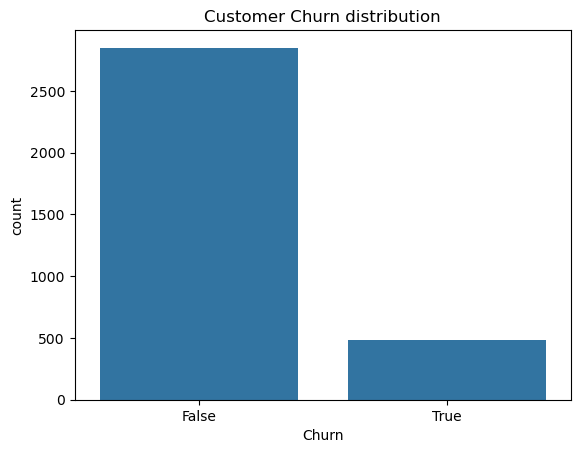

In [18]:
#plot churn distribution
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn distribution");

**Observation**

- There is a significant larger number of customers classified as non-churners (false), compared to churners (true).

### 3.3.2 Bivariate Analysis

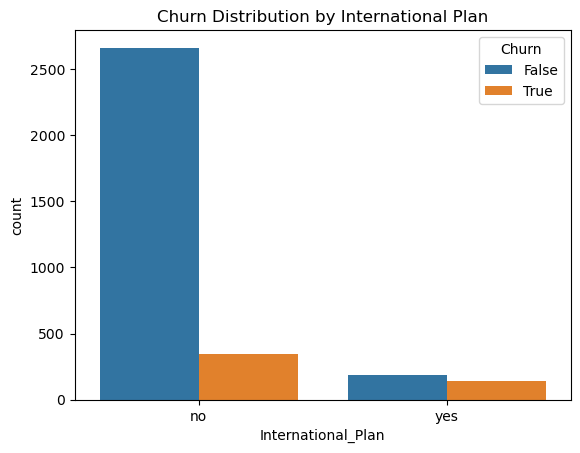

In [19]:
#plot to show how many customers with or without an international plan have churned
sns.countplot(data=df, x="International_Plan", hue="Churn")
plt.title("Churn Distribution by International Plan");

**Observation**
- Majority of customers do not have an international plan and within that group, the churn rate is significantly lower compared to the group with an international plan, which exhibits a higher proportion of churned customers relative to non-churned customers.

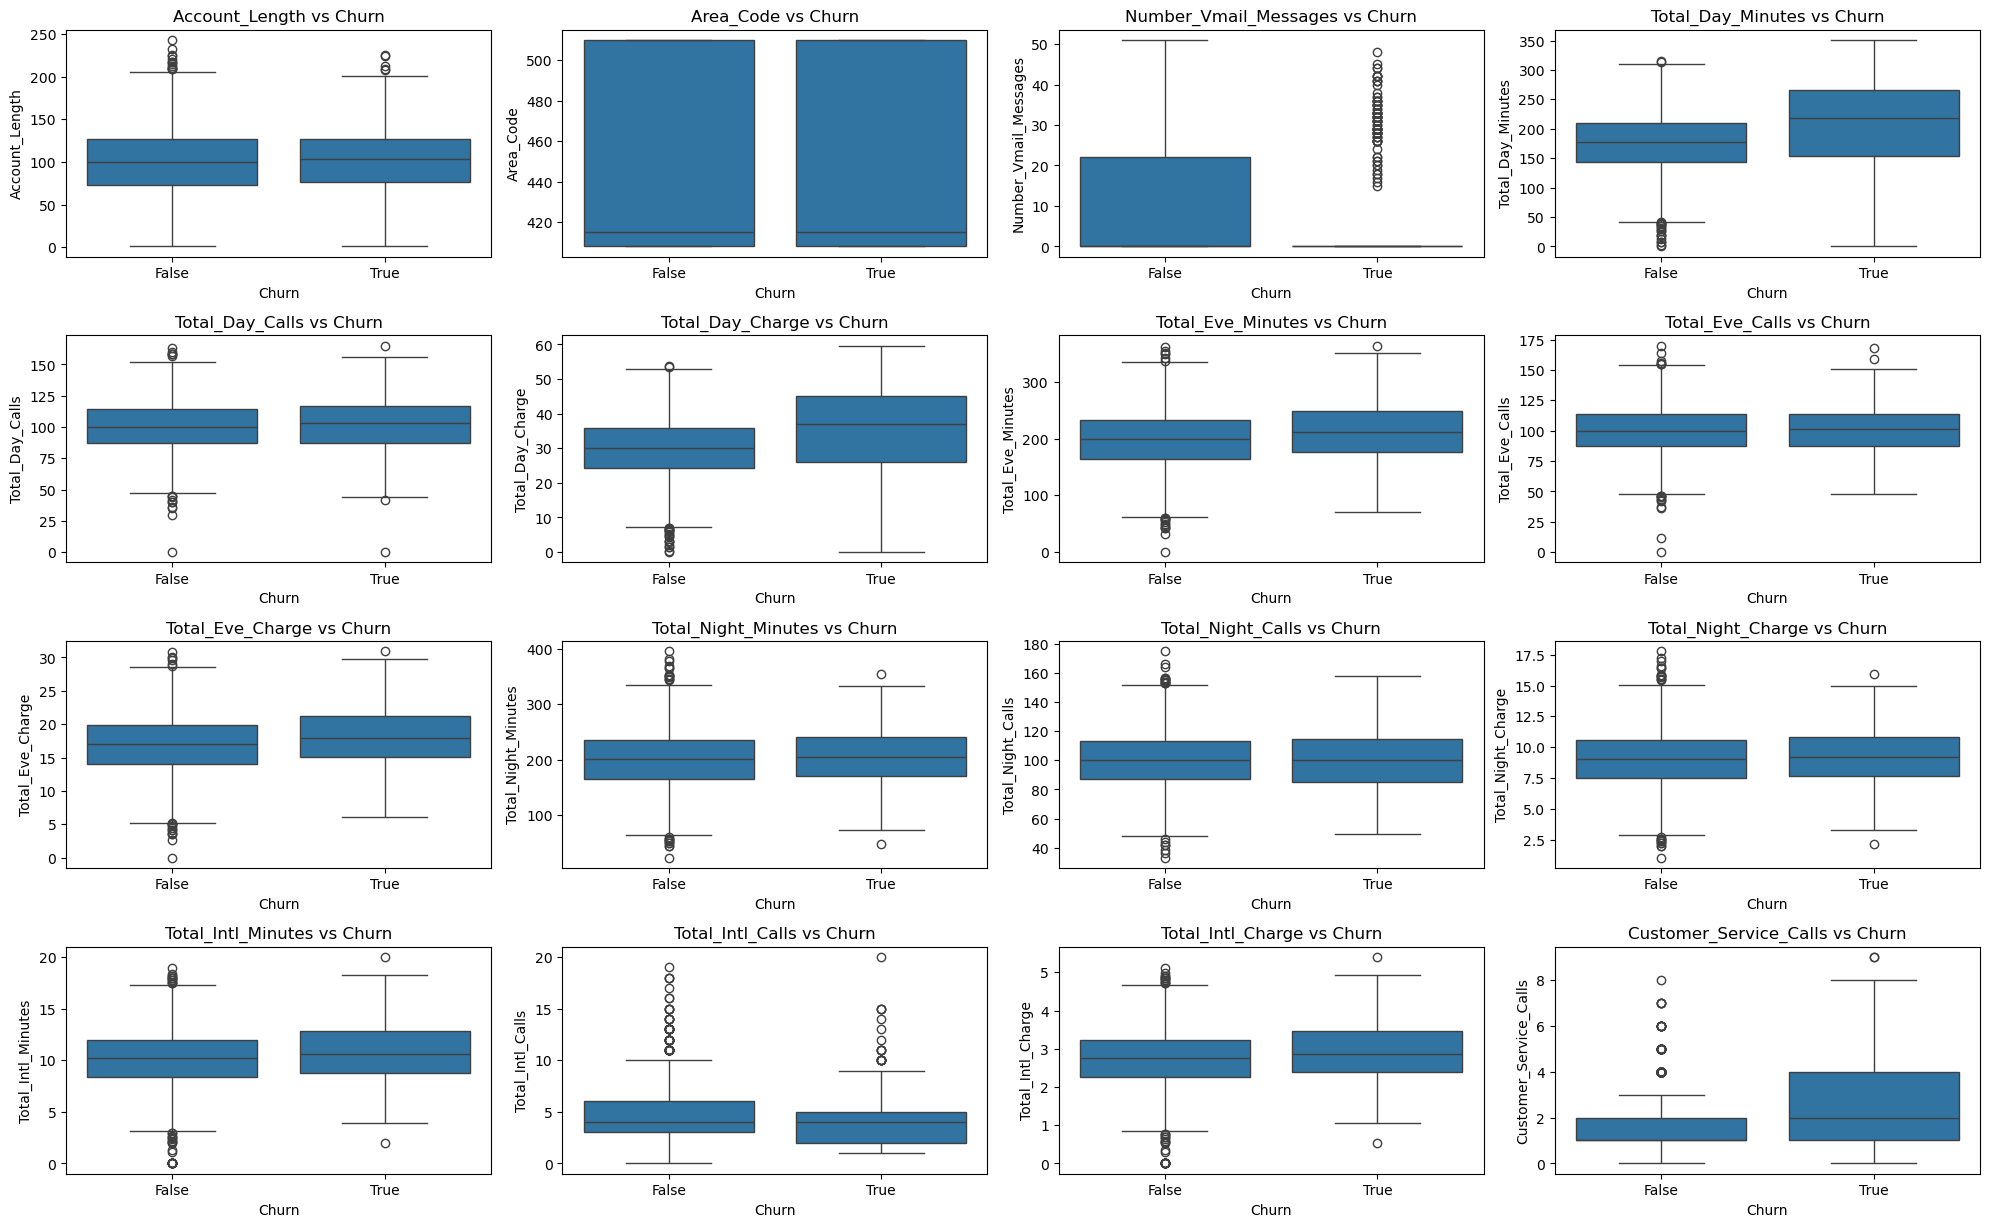

In [20]:
#numerical variables vs churn
numeric_cols = df.select_dtypes(include="number")

plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} vs Churn")
plt.tight_layout();

### 3.3.3 Multivariate Analysis

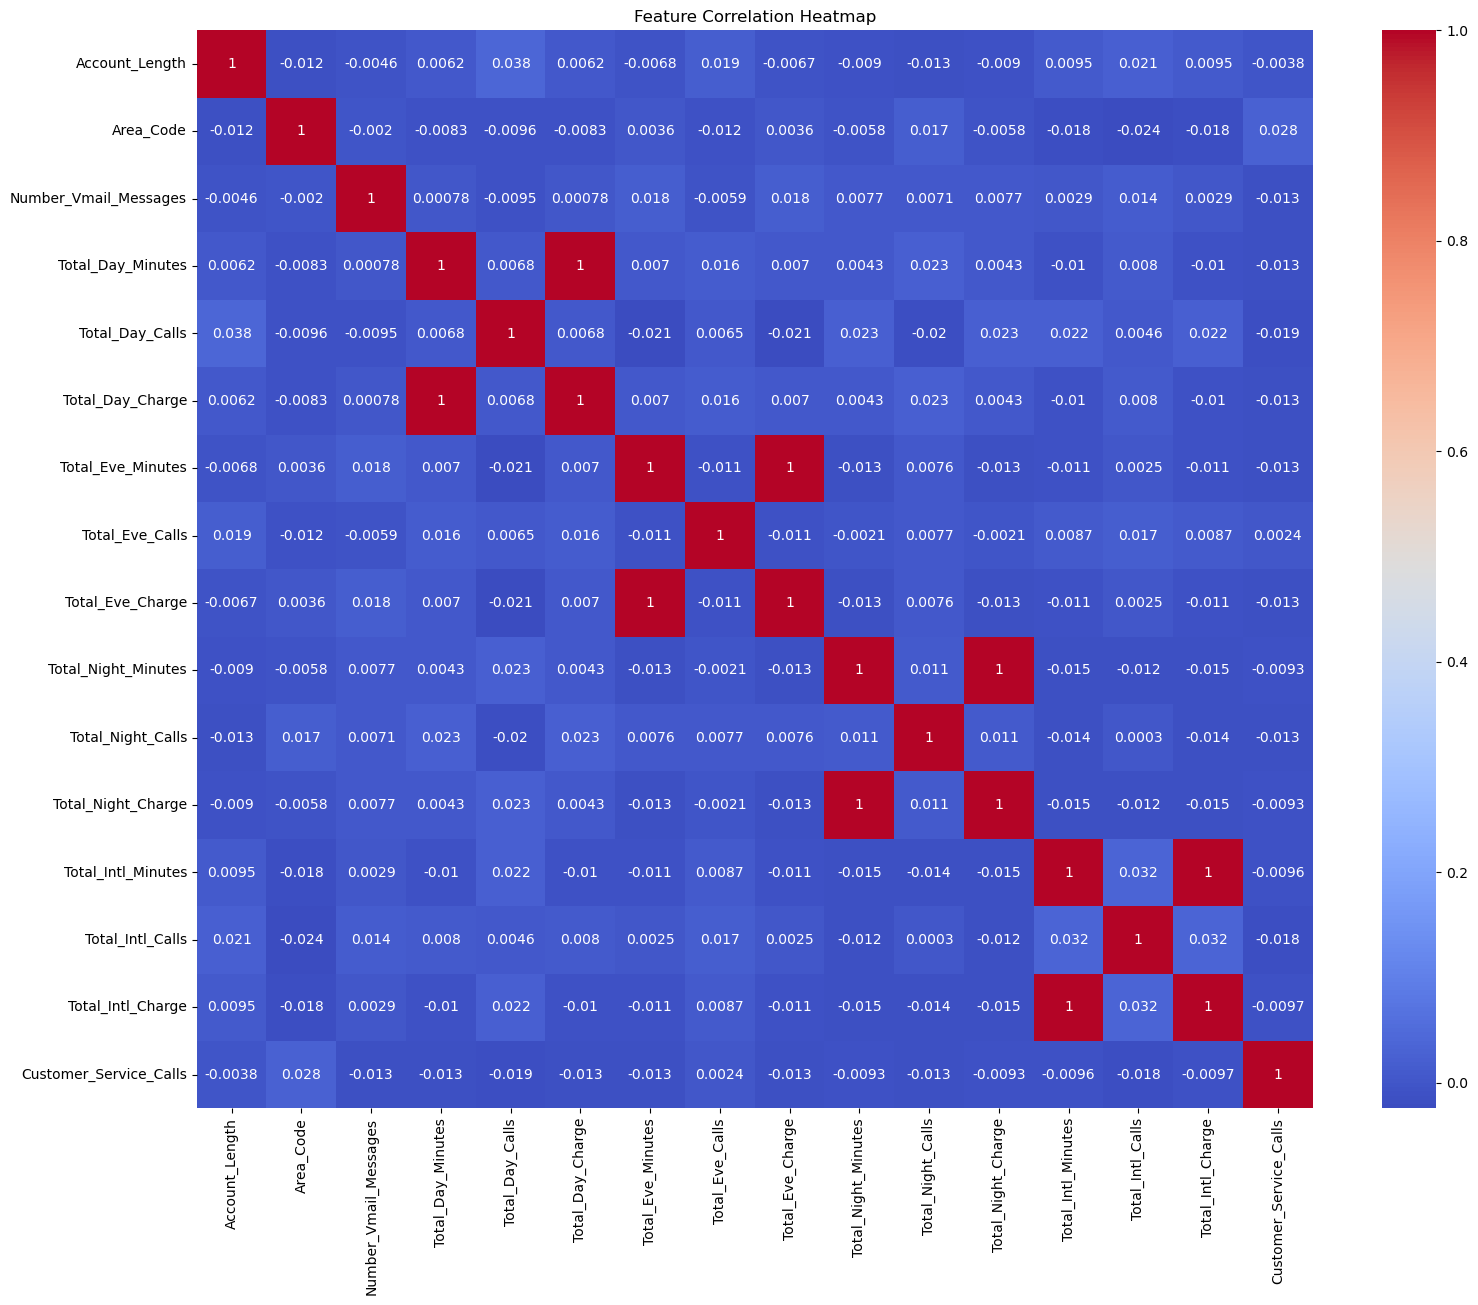

In [21]:
#select only numeric columns from the DataFrame
numeric_df = df.select_dtypes(include=["number"])

#plot a correlation heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap");

**Observations**
- The heatmap shows strong positive correlations between corresponding duration and charge features, such as "total day minutes" and "total day charge", "total eve minutes" and "total eve charge" etc.

- There are no significantly high correlations outside of duration-charge pairs.

### 3.4 Feature Engineering

In [22]:
#Total minutes spent on calls
df["Total_Minutes"] = (
    df["Total_Day_Minutes"]
    + df["Total_Eve_Minutes"] 
    + df["Total_Night_Minutes"]
    )

#Total calls
df["Total_Calls"] = (
    df["Total_Day_Calls"] 
    + df["Total_Eve_Calls"] 
    + df["Total_Night_Calls"]
    )

#Total charges
df["Total_Charges"] = (
    df["Total_Day_Charge"] 
    + df["Total_Eve_Charge"] 
    + df["Total_Night_Charge"]
    )

#Charges per minute
df["Charges_Per_Minute"] = df["Total_Charges"] / df["Total_Minutes"]

#Average call duration in minutes
df["Avg_Call_Duration"] = df["Total_Minutes"] / df["Total_Calls"]

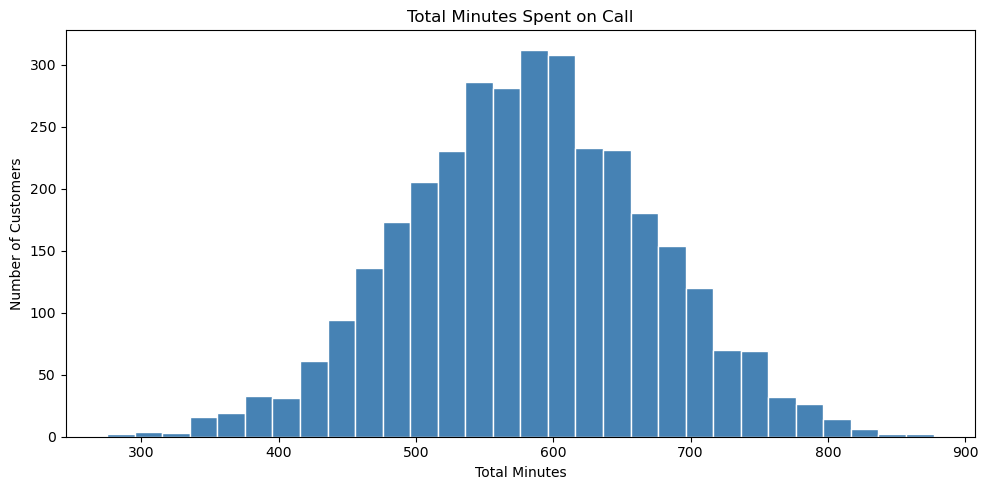

In [23]:
#plot for total minuites spent on calls

plt.figure(figsize=(10, 5))
plt.hist(df["Total_Minutes"], bins=30, color="steelblue", edgecolor="white")
plt.title("Total Minutes Spent on Call")
plt.xlabel("Total Minutes")
plt.ylabel("Number of Customers")
plt.tight_layout();

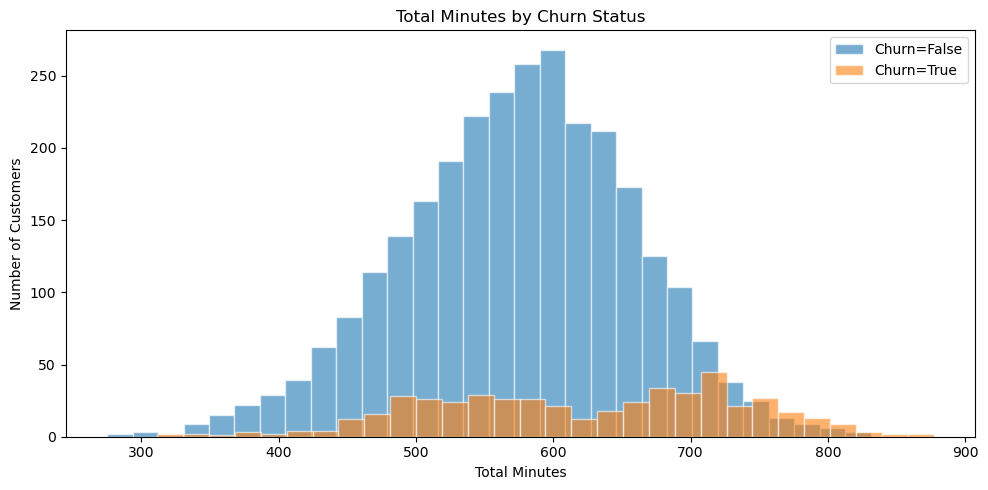

In [24]:
#plot for total minutes spent on calls based on churn status

fig, ax = plt.subplots(figsize=(10, 5))
for churn, group in df.groupby("Churn"):
    ax.hist(group["Total_Minutes"], bins=30, alpha=0.6, label=f"Churn={churn}", edgecolor="white")

plt.title("Total Minutes by Churn Status")
plt.xlabel("Total Minutes")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout();

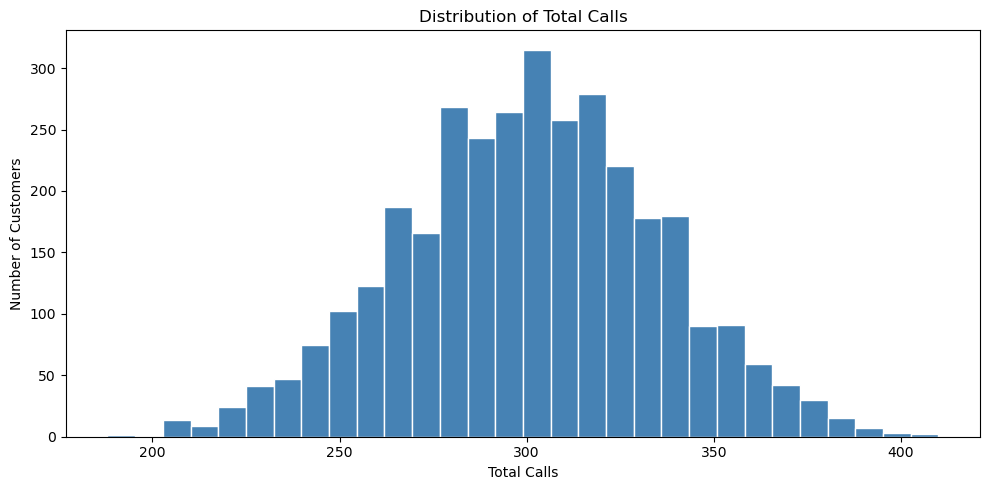

In [120]:
#plot for total calls

plt.figure(figsize=(10, 5))
plt.hist(df["Total_Calls"], bins=30, color="steelblue", edgecolor="white")
plt.title("Distribution of Total Calls")
plt.xlabel("Total Calls")
plt.ylabel("Number of Customers")
plt.tight_layout();

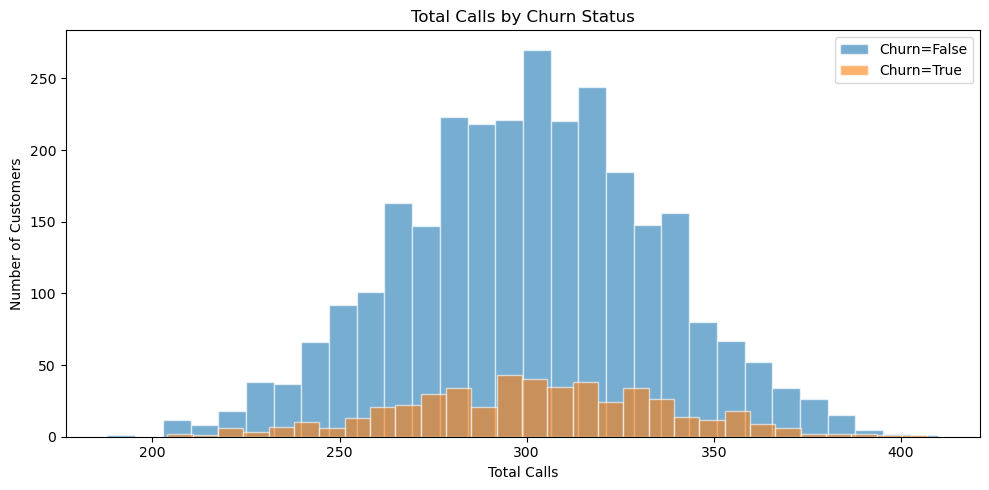

In [ ]:
#plot for total calls based on churn status

fig, ax = plt.subplots(figsize=(10, 5))
for churn, group in df.groupby("Churn"):
    ax.hist(group["Total_Calls"], bins=30, alpha=0.6, label=f"Churn={churn}", edgecolor="white")

plt.title("Total Calls by Churn Status")
plt.xlabel("Total Calls")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout();

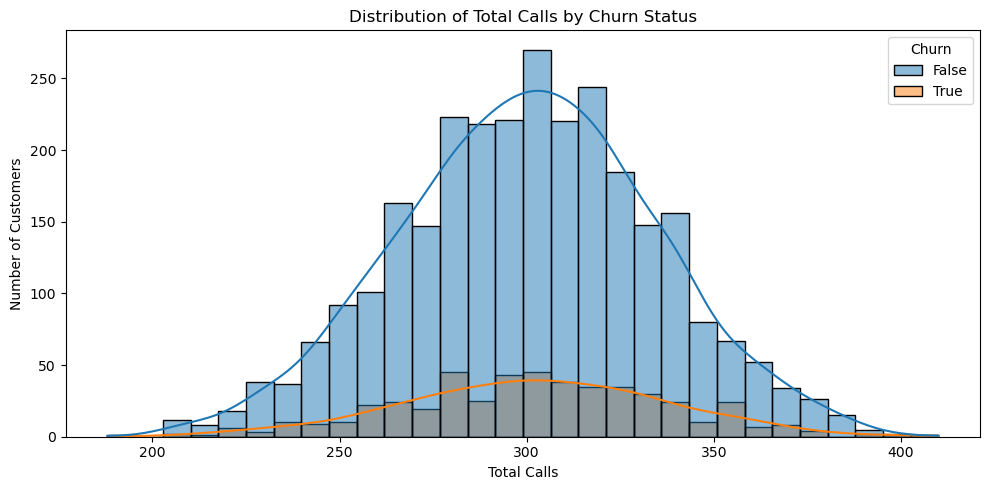

In [121]:
#plot for total calls based on churn status

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Total_Calls", hue="Churn", bins=30, kde=True)
plt.title("Distribution of Total Calls by Churn Status")
plt.xlabel("Total Calls")
plt.ylabel("Number of Customers")
plt.tight_layout();

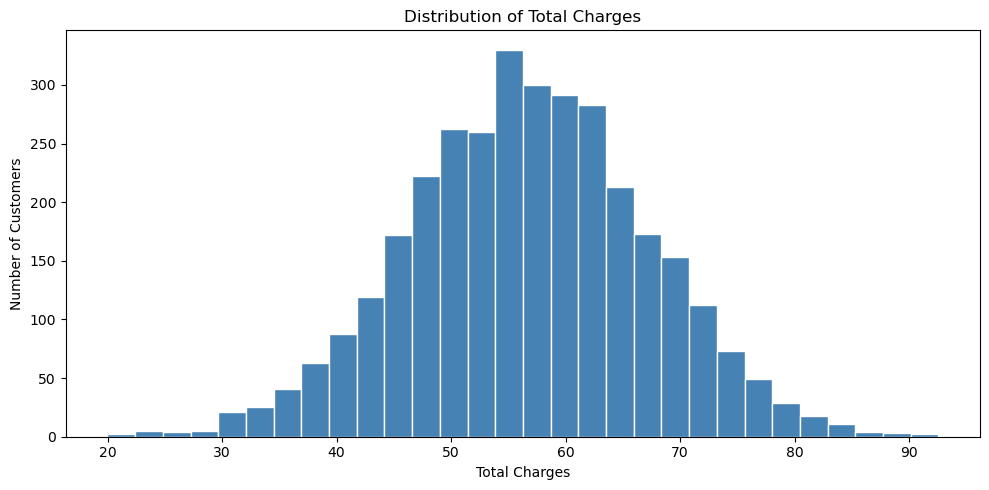

In [122]:
#plot for total charges

plt.figure(figsize=(10, 5))
plt.hist(df["Total_Charges"], bins=30, color="steelblue", edgecolor="white")
plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.tight_layout();

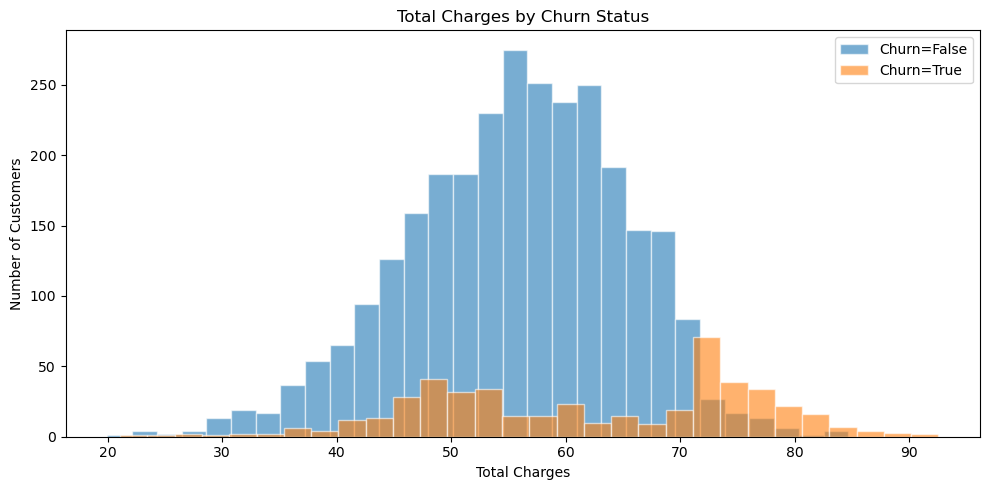

In [123]:
#plot for churned vs non-churned customers based on total charges

fig, ax = plt.subplots(figsize=(10, 5))
for churn, group in df.groupby("Churn"):
    ax.hist(group["Total_Charges"], bins=30, alpha=0.6, label=f"Churn={churn}", edgecolor="white")

plt.title("Total Charges by Churn Status")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout();

In [124]:
#drop columns
df = df.drop(columns =["State", "Phone_Number"])

In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Account_Length          3333 non-null   int64  
 1   Area_Code               3333 non-null   int64  
 2   International_Plan      3333 non-null   str    
 3   Voice_Mail_Plan         3333 non-null   str    
 4   Number_Vmail_Messages   3333 non-null   int64  
 5   Total_Day_Minutes       3333 non-null   float64
 6   Total_Day_Calls         3333 non-null   int64  
 7   Total_Day_Charge        3333 non-null   float64
 8   Total_Eve_Minutes       3333 non-null   float64
 9   Total_Eve_Calls         3333 non-null   int64  
 10  Total_Eve_Charge        3333 non-null   float64
 11  Total_Night_Minutes     3333 non-null   float64
 12  Total_Night_Calls       3333 non-null   int64  
 13  Total_Night_Charge      3333 non-null   float64
 14  Total_Intl_Minutes      3333 non-null   float64
 15

In [126]:
#check class imbalance
df["Churn"].value_counts(normalize=True) * 100

Churn
False    85.508551
True     14.491449
Name: proportion, dtype: float64

There is class imbalance as;
- 85.5% of customers did not churn.
- 14.5% of customers churned

### 3.5 Preprocessing

In [127]:
#label encode the target variable
encoder = LabelEncoder()
df["Churn"] = encoder.fit_transform(df["Churn"])

In [128]:
#define categorical columns to encode
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
categorical_cols

C:\Users\Felix\AppData\Local\Temp\ipykernel_12644\2830926788.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns


Index(['International_Plan', 'Voice_Mail_Plan'], dtype='str')

In [129]:
#label encode categorical columns
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Account_Length,Area_Code,International_Plan,Voice_Mail_Plan,Number_Vmail_Messages,Total_Day_Minutes,Total_Day_Calls,Total_Day_Charge,Total_Eve_Minutes,Total_Eve_Calls,Total_Eve_Charge,Total_Night_Minutes,Total_Night_Calls,Total_Night_Charge,Total_Intl_Minutes,Total_Intl_Calls,Total_Intl_Charge,Customer_Service_Calls,Churn,Total_Minutes,Total_Calls,Total_Charges,Charges_Per_Minute,Calls_Per_Minute
0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0,707.2,300,72.86,0.103026,0.424208
1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0,611.5,329,55.54,0.090826,0.538021
2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0,527.2,328,59.00,0.111912,0.622155
3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0,558.2,248,65.02,0.116482,0.444285
4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0,501.9,356,49.36,0.098346,0.709305


In [130]:
#divide the data into target and predictors
X = df.drop("Churn", axis=1)
y = df["Churn"]

## 4. Modeling

Three models will be created namely;
1. Baseline model - simple logistic regression model
2. Random Forest - without optimal hyperparameters
3. Random Forest - using optimal hyperparameters

In [131]:
#split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)

In [132]:
#scale the features

#initialize the standard scaler
scaler = StandardScaler()

#fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4.1 Logistic Regression

In [133]:
#build logistic regression as the baseline model
lr_model = LogisticRegression()
#fit the model
lr_model.fit(X_train_scaled, y_train)

#predict y
y_pred = lr_model.predict(X_test_scaled)

#evaluate the model
print(f"\n{lr_model} Performance:")
print("------------------------------------------------------------")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy Score:", round(accuracy_score(y_test, y_pred),2)*100)


LogisticRegression() Performance:
------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       570
           1       0.58      0.34      0.43        97

    accuracy                           0.87       667
   macro avg       0.74      0.65      0.68       667
weighted avg       0.85      0.87      0.85       667

Accuracy Score: 87.0


- The model correctly predicts 87% of cases (accuracy)
- Recall for Class 1 (Churn) is only 0.34, meaning 66% of actual churners are missed.
- The model is biased toward predicting "Non-Churn" (0) due to class imbalance thus fails to recall enough churn cases.
- The model has a f1-score of 0.43 indicating that it struggles to detect churn customers correctly.


**We can try Random Forest which is better at handling imbalanced data, to improve recall.**

### 4.2 Random Forest

In [134]:
#initialize Random Forest Model
rf_model = RandomForestClassifier(random_state=42)
#fit the model
rf_model.fit(X_train, y_train)

#predict y
y_pred2 = rf_model.predict(X_test)

#evaluate the Model
print(f"\n{rf_model} Performance:")
print("-------------------------------------------------------------------------")
print("\nClassification Report:")
print(classification_report(y_test, y_pred2))
print("Accuracy Score:", round(accuracy_score(y_test, y_pred2) * 100, 2), "%")


RandomForestClassifier(random_state=42) Performance:
-------------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       570
           1       0.94      0.75      0.83        97

    accuracy                           0.96       667
   macro avg       0.95      0.87      0.90       667
weighted avg       0.96      0.96      0.95       667

Accuracy Score: 95.65 %


Our second model uses random forest, which has an accuracy of 95.65%.

Random Forest performs significantly better than logistic regression especially in detecting churn (1)

Recall for Churn increased from 34%(Logistic Regression) to 75%

25% of actual churners are still being misclassified as Non-Churn meaning, some customers who will leave are not being detected.

We can therefore, tune the Model Using hyper-parameter optimization, to further boost recall for churn.

### 4.2.1 Hyperparameter Tuning for Random Forest

To optimize the Random Forest model, we need to fine-tune hyperparameters to improve performance.

We will use GridSearchCV to find the best hyperparameters for the Random Forest Model.

This will help in improving performance, particularly in detecting churn customers.

In [135]:
#define the parameter grid
param_grid = {
    #number of trees
    "n_estimators": [100, 200, 300],
    #depth of trees
    "max_depth": [5, 10, 20],
    # min samples to split a node
    "min_samples_split": [2, 5, 10],
    #min samples in a leaf
    "min_samples_leaf": [1, 2, 4],
    #handling class imbalance
    "class_weight": [None, 'balanced']
}

#initialize the RandomForest model
rf_model = RandomForestClassifier(random_state=42)

#initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    # Optimize for recall (important for churn prediction)
    scoring='recall',
    # 5-fold cross-validation
    cv=5,
    # Use all CPU cores for faster search
    n_jobs=-1,
    # Show progress
    verbose=2
)

#fit GridSearchCV on training data
grid_search.fit(X_train, y_train)

#print best parameters
print("Best Hyperparameters:", grid_search.best_params_)


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Hyperparameters: {'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


**Retrain with Best Parameters**

Retraining the model with best parameters obtained above

In [136]:
#use the best parameters from GridSearchCV
best_rf = RandomForestClassifier(
    class_weight=None,
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)

#fit the optimized model on the training data
best_rf.fit(X_train, y_train)

#predict y on test data
y_pred_best = best_rf.predict(X_test)

#evaluate performance
print("\nOptimized Random Forest Performance:")
print(classification_report(y_test, y_pred_best))
print("Accuracy Score:", round(accuracy_score(y_test, y_pred_best) * 100, 2), "%")


Optimized Random Forest Performance:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       570
           1       0.94      0.74      0.83        97

    accuracy                           0.96       667
   macro avg       0.95      0.87      0.90       667
weighted avg       0.95      0.96      0.95       667

Accuracy Score: 95.5 %


The performance is similar to the untuned Random Forest model.

But with a Recall of 0.74, some churners are still being misclassified as non-churners.

**Since recall was still low, I incorporated adjust prediction threshold which manually adjusts the classification threshold.**

In [137]:
#use the best parameters from GridSearchCV
best_rf = RandomForestClassifier(
    class_weight=None,
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)

#fit the optimized model on the training data
best_rf.fit(X_train, y_train)

#y Predict on test data
y_pred_best = best_rf.predict(X_test)

#get churn probabilities
y_proba = best_rf.predict_proba(X_test)[:, 1]

#lower threshold to favor churners
y_pred_best = (y_proba > 0.3).astype(int)


#evaluate performance
print("\nOptimized Random Forest Performance:")
print(classification_report(y_test, y_pred_best))
print("Accuracy Score:", round(accuracy_score(y_test, y_pred_best) * 100, 2), "%")


Optimized Random Forest Performance:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       570
           1       0.91      0.81      0.86        97

    accuracy                           0.96       667
   macro avg       0.94      0.90      0.92       667
weighted avg       0.96      0.96      0.96       667

Accuracy Score: 96.1 %


Adjusting the prediction threshold helped improve recall while keeping a strong precision and accuracy.

There was a slight drop in precision suggesting more false positives (non-churners incorrectly classified as churners).
This is expected when shifting the threshold to favor recall over precision.

This is a great trade-off for churn prediction, where missing actual churners (false negatives) is more costly than a few false positives.

The model is now more sensitive to detecting churners.

### Final Model

Based on the analysis, the optimized Random Forest model with an adjusted prediction threshold is the preferred choice for predicting customer churn. This is because, the model handles class imbalance well. The dataset has more non-churners than churners, and Random Forest (with class weighting or threshold tuning) helps balance predictions.

Additionally, the model has a strong predictive power. With high feature importance in Total_Charges, Customer_Service_Calls, and International_Plan, Random Forest captures key patterns effectively. Feature importance plot also helps in understanding customer behavior and designing targeted retention strategies.

Lastly, the model is flexible. This is because threshold tuning allows for adjusting model sensitivity depending on business needs such as prioritizing recall over precision to reduce churn losses, while maintaining a strong overall accuracy.

### 4.3 Feature Importance

- Gini Importance

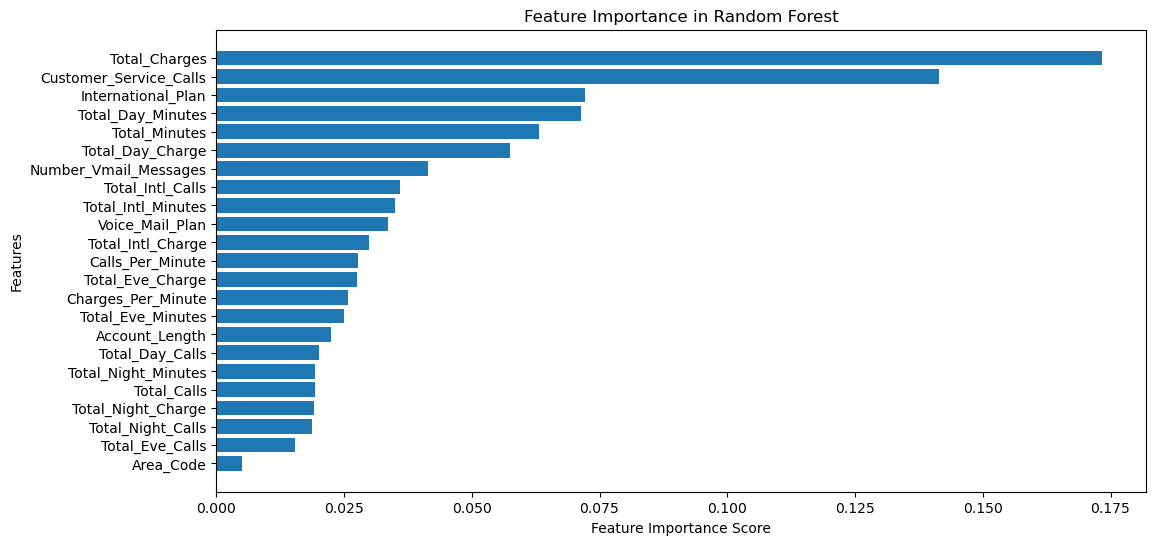

In [138]:
# Get feature importances
feature_importances = best_rf.feature_importances_

# Create a DataFrame for visualization
features = X_train.columns
importance_df = pd.DataFrame({"Feature": features, "Importance": feature_importances})

# Sort by importance
importance_df = importance_df.sort_values(by="Importance", ascending=True)

# Plot the feature importances
plt.figure(figsize=(12, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest");

**Observations**

The Top 5 Contributing Features are:
- Total_Charges
- Customer_Service_Calls
- International_Plan
- Total_Day_Minutes
- Total_Minutes

Total_Charges is the most influential factor in predicting churn.

Customer_Service_Calls has a high importance, suggesting that customers who make more service calls are more likely to churn.

International_Plan is a strong indicator, possibly because customers with international plans have different churn behaviors.

Total_Day_Minutes & Total_Minutes suggest that the total duration of calls plays a major role in churn prediction.

## 5. Evaluation

### 5.1 Confusion Matrix

The confusion matrix summarizes the predictions against the actual outcomes,giving us an indication of how well the model does at predicting the churners.

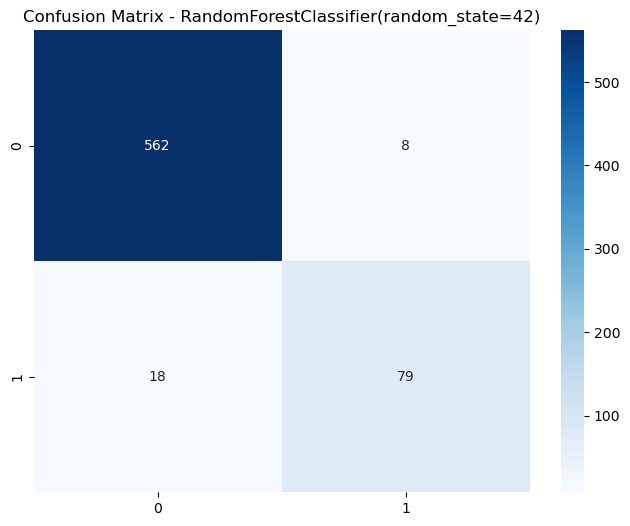

In [139]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap="Blues")
plt.title(f'Confusion Matrix - {rf_model}');

Based on the confusion matrix;

The True Negatives are 562, meaning 562 customers were correctly predicted not to churn.

The True Positives are 79, meaning 79 customers were correctly predicted to churn.

The False Negatives are 8, meaning 8 customers actually churned but were predicted not to.

The False Positives are 18, meaning 18 customers were wrongly predicted to churn but they did not actually churn.

### 5.2 ROC-AUC Curve

We are going to validate the model's performance using ROC Curve and AUC Score.

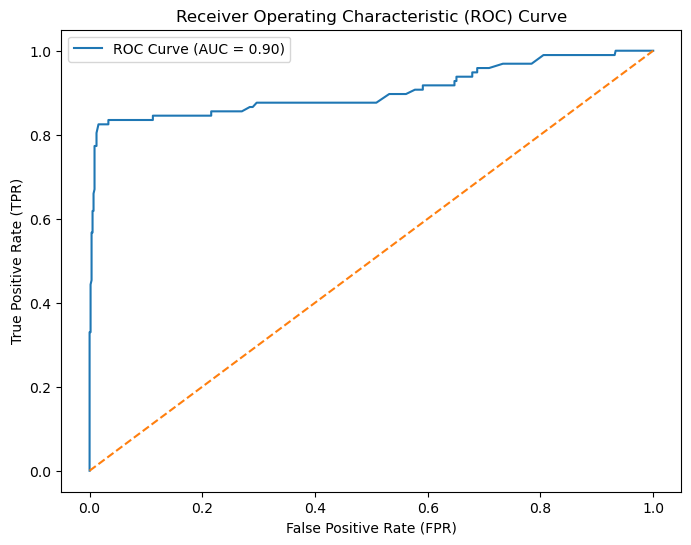

AUC Score: 0.90


In [140]:
#get the predicted probabilities for the positive class (churn = 1)
y_probs = best_rf.predict_proba(X_test)[:, 1]

#calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

#calculate AUC score
auc_score = roc_auc_score(y_test, y_probs)

#plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()

#print AUC Score
print(f"AUC Score: {auc_score:.2f}")


**Observations**

An AUC of 0.90 suggests strong predictive power (90% chance that a randomly chosen churner is ranked higher than a non-churner)

The model's ROC curve is well above the diagonal, indicating good classification ability.

The steep initial rise is ideal as the model captures a high TPR (Recall) early while keeping FPR low.


## 5.3 Findings

1. The preferred classification model for predicting customer churn is the Random Forest model with an adjusted prediction threshold.

2. The initial Random Forest model had high accuracy but a recall of 0.74 for churners, indicating that many actual churners were misclassified.

3. Using GridSearchCV, we optimized parameters like max_depth, n_estimators, and min_samples_split, improving overall performance but not significantly increasing recall for churners.

4. Adjusting the classification threshold led to a recall increase from 0.74 to 0.81, meaning more actual churners were correctly identified. Precision remained strong at 0.91, and overall accuracy was 96.1%.

5. The AUC score of 0.90 indicates a well-performing model with a good trade-off between sensitivity and specificity.

6. The most important features influencing churn were:
- Total Charges (higher charges increase churn likelihood)
- Customer Service Calls (frequent calls correlate with churn).
- International Plan (subscribers to this plan are more likely to churn).


## 5.4 Recommendations

- SyriaTel should implement the optimized Random Forest model with threshold adjustment, as it balances recall and precision effectively.

- The company should target high-risk customers (e.g., those with high charges and frequent customer service interactions) with personalized offers and better customer support.

- SyriaTel should improve customer service quality to reduce dissatisfaction and churn risk.

- The company should offer incentives to customers on the International Plan to increase retention.

- Further improvements can be made by exploring alternative models such as XGBoost.